# **nalara.academy**

## **Modul 3 - AI & Machine Learning**
### **Sesi 4: Unsupervised Learning sebagai "Sihir Visual"**

### **📌 Pengantar Sesi**
Setelah tiga sesi penuh logika matematis (cleaning, EDA, training, evaluasi), sesi terakhir ini
adalah **taman bermain visual**. Kita akan memahami konsep **Clustering** (pengelompokan tanpa
kunci jawaban / *Unsupervised Learning*) melalui efek visual yang langsung terlihat hasilnya:
mengubah foto menjadi seni **Pop-Art** menggunakan algoritma **K-Means Color Quantization**.

Tidak ada `model.fit()` yang butuh data berlabel di sini — komputer akan mencari sendiri
warna-warna dominan dalam gambar, murni dari pola datanya.

## **🎨 1. Konsep Color Quantization dengan K-Means**

**Color Quantization** adalah proses mengurangi jumlah warna unik dalam sebuah gambar menjadi
sejumlah kecil warna representatif, tanpa mengubah bentuk objek di dalamnya.

Bayangkan sebuah foto memiliki jutaan kombinasi warna berbeda (gradasi halus). **K-Means**
bekerja dengan cara:

1. Menganggap setiap piksel sebagai satu titik data di ruang warna 3D (Red, Green, Blue)
2. Menentukan **K** titik pusat (centroid) warna secara acak
3. Mengelompokkan setiap piksel ke centroid warna terdekat
4. Menghitung ulang posisi centroid berdasarkan rata-rata piksel anggotanya
5. Mengulangi langkah 3-4 sampai posisi centroid stabil (konvergen)

Hasil akhirnya: seluruh piksel gambar "dipaksa" hanya menggunakan **K warna saja** — semakin
kecil K, semakin terasa efek Pop-Art-nya.

```
Gambar Asli (jutaan warna)        Setelah K-Means (K=4)
   ░▒▓█▓▒░▒▓█                          ████
   ▒▓█░▒▓█▒░                    -->    ████
   ▓█▒░▓█▒░▓                           ████
   (gradasi halus)                  (4 warna blok)
```

### **Elbow Method — Menentukan Jumlah K secara Matematis**

Untuk menentukan jumlah cluster K yang "ideal" secara matematis (bukan asal tebak), biasanya
digunakan **Elbow Method**: mencoba berbagai nilai K dan melihat titik di mana penambahan K
tidak lagi memberikan penurunan error (*inertia*) yang signifikan — membentuk pola seperti
siku (*elbow*) pada grafik.

> 💡 Di sesi ini kita hanya akan **melihat sekilas** konsep Elbow Method sebagai wawasan,
> karena fokus utama sesi ini adalah eksplorasi visual, bukan optimasi matematis K secara ketat.

## **🖼️ 2. Memuat Gambar Sampel: china.jpg**

Kita menggunakan gambar sampel bawaan dari `scikit-learn`, yaitu `china.jpg` — foto pemandangan
dengan variasi warna yang kaya, cocok untuk mendemonstrasikan efek color quantization.

📐 Shape gambar asli : (427, 640, 3)
   -> (427 tinggi, 640 lebar, 3 channel warna)
🔢 Tipe data piksel  : uint8  (rentang nilai 0-255)


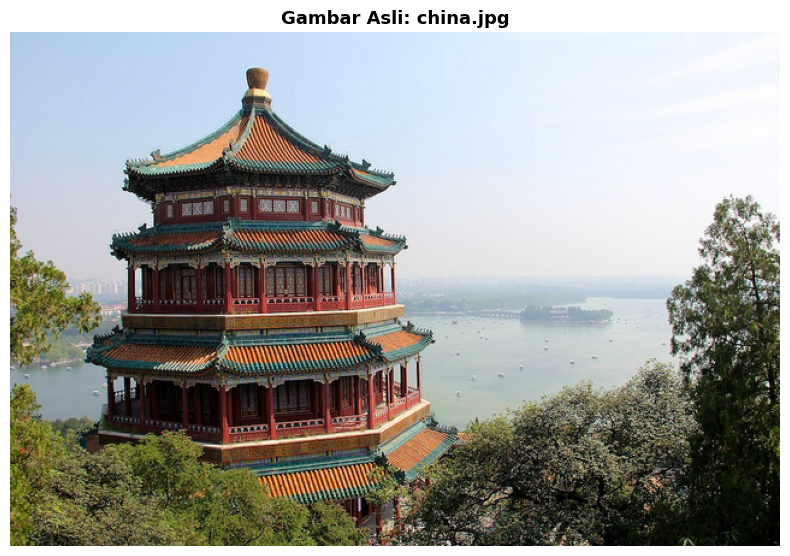

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image
from sklearn.cluster import KMeans
import os

%matplotlib inline

# Memuat gambar sampel bawaan scikit-learn
china = load_sample_image("china.jpg")

print(f"📐 Shape gambar asli : {china.shape}")
print(f"   -> ({china.shape[0]} tinggi, {china.shape[1]} lebar, {china.shape[2]} channel warna)")
print(f"🔢 Tipe data piksel  : {china.dtype}  (rentang nilai 0-255)")

plt.figure(figsize=(8, 6))
plt.imshow(china)
plt.title("Gambar Asli: china.jpg", fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

## **⚙️ 3. Fungsi Siap Pakai: `efek_kmeans()`**

Berikut fungsi Python siap pakai untuk mengaplikasikan efek K-Means Color Quantization pada
gambar apapun. Anda tidak perlu memahami detail matematisnya secara mendalam — fokuslah pada
**bereksperimen** mengubah parameter `jumlah_warna` dan amati hasilnya.

In [10]:
def efek_kmeans(gambar, jumlah_warna):
    """
    Menerapkan efek Color Quantization menggunakan K-Means.

    Parameter:
        gambar       : array gambar dengan shape (tinggi, lebar, 3)
        jumlah_warna : jumlah cluster warna (K) yang diinginkan

    Mengembalikan:
        Gambar baru dengan jumlah warna unik yang sudah direduksi menjadi K warna.
    """
    tinggi, lebar, channel = gambar.shape

    # K-Means bekerja pada data 2D: ubah gambar (H, W, 3) menjadi daftar piksel (H*W, 3)
    # Normalisasi ke rentang 0-1 agar komputasi lebih stabil
    data_piksel = gambar.reshape(-1, channel) / 255.0

    # Latih K-Means -- setiap piksel akan dikelompokkan ke salah satu dari K cluster warna
    kmeans = KMeans(n_clusters=jumlah_warna, random_state=42, n_init=10)
    label_cluster = kmeans.fit_predict(data_piksel)

    # Ganti setiap piksel dengan warna centroid cluster-nya
    warna_centroid = kmeans.cluster_centers_
    gambar_hasil = warna_centroid[label_cluster].reshape(tinggi, lebar, channel)

    # Kembalikan ke rentang 0-255 dan tipe data uint8 (format gambar standar)
    gambar_hasil = (gambar_hasil * 255).astype(np.uint8)

    return gambar_hasil, warna_centroid

print("✅ Fungsi efek_kmeans() siap digunakan.")

✅ Fungsi efek_kmeans() siap digunakan.


## **🧪 4. Eksplorasi: Bereksperimen dengan Berbagai Nilai K**

Sekarang giliran Anda bereksperimen! Ubah nilai `jumlah_warna` di bawah ini dan amati bagaimana
gambar berubah wujud.

> ⏳ Proses K-Means pada gambar beresolusi penuh bisa memakan waktu beberapa saat,
> terutama untuk nilai K yang besar — harap bersabar menunggu proses selesai.

In [11]:
# Coba beberapa nilai K sekaligus untuk perbandingan langsung
nilai_k_list = [2, 4, 10]

print("⏳ Memproses K-Means untuk beberapa nilai K, mohon tunggu...")
hasil_kmeans = {}
for k in nilai_k_list:
    gambar_hasil, centroid = efek_kmeans(china, k)
    hasil_kmeans[k] = (gambar_hasil, centroid)
    print(f"   ✅ K={k} selesai diproses.")

print("\n✅ Semua proses selesai!")

⏳ Memproses K-Means untuk beberapa nilai K, mohon tunggu...
   ✅ K=2 selesai diproses.
   ✅ K=4 selesai diproses.
   ✅ K=10 selesai diproses.

✅ Semua proses selesai!


C:\Users\Asus\AppData\Local\Temp\ipykernel_17724\511053889.py:15: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


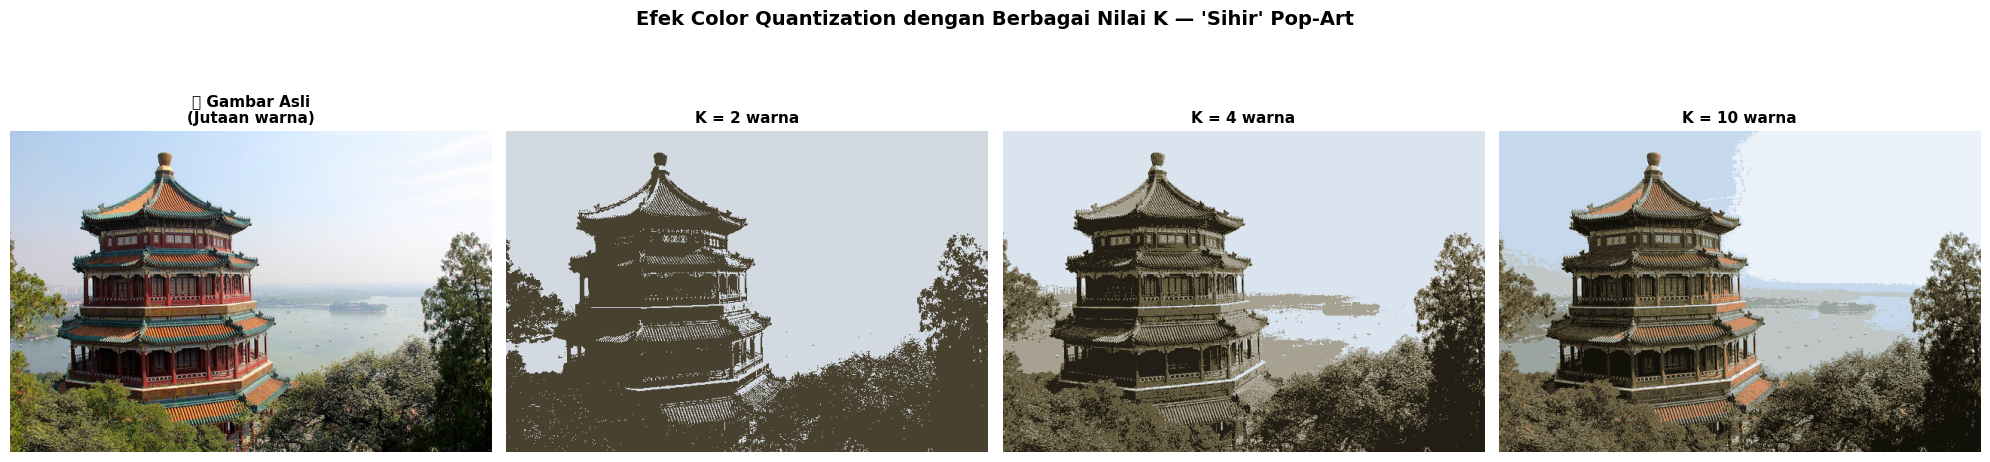

💡 Perhatikan: semakin kecil K, semakin terasa efek 'blok warna' ala Pop-Art.
   Semakin besar K, gambar makin mendekati tampilan aslinya.


In [12]:
fig, axes = plt.subplots(1, len(nilai_k_list) + 1, figsize=(20, 5))

axes[0].imshow(china)
axes[0].set_title("🖼️ Gambar Asli\n(Jutaan warna)", fontsize=11, fontweight="bold")
axes[0].axis("off")

for ax, k in zip(axes[1:], nilai_k_list):
    gambar_hasil, _ = hasil_kmeans[k]
    ax.imshow(gambar_hasil)
    ax.set_title(f"K = {k} warna", fontsize=11, fontweight="bold")
    ax.axis("off")

plt.suptitle("Efek Color Quantization dengan Berbagai Nilai K — 'Sihir' Pop-Art",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print("💡 Perhatikan: semakin kecil K, semakin terasa efek 'blok warna' ala Pop-Art.")
print("   Semakin besar K, gambar makin mendekati tampilan aslinya.")

## **🎨 5. Melihat Palet Warna Dominan yang Ditemukan K-Means**

Salah satu hal menarik dari K-Means adalah ia bisa memberi tahu kita **warna apa saja yang
paling dominan** dalam sebuah gambar — murni dari pola data, tanpa kita beri tahu sebelumnya
warna apa itu.

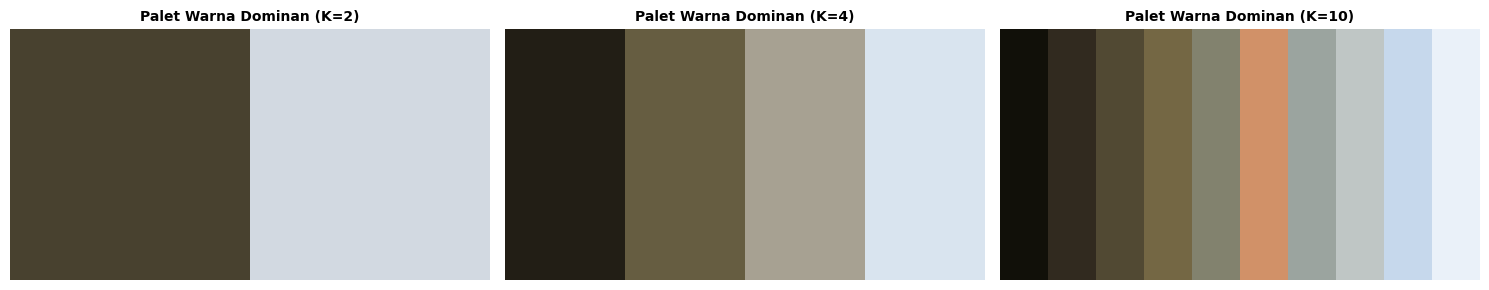

💡 Inilah hasil 'sihir' Unsupervised Learning: komputer menemukan sendiri warna-warna
   dominan pada gambar, tanpa pernah diberi tahu 'ini warna hijau', 'ini warna biru', dst.


In [13]:
fig, axes = plt.subplots(1, len(nilai_k_list), figsize=(15, 3))

for ax, k in zip(axes, nilai_k_list):
    _, centroid = hasil_kmeans[k]
    # Urutkan warna agar tampilan palet lebih enak dilihat (berdasarkan tingkat kecerahan)
    centroid_terurut = centroid[np.argsort(centroid.sum(axis=1))]

    palet = centroid_terurut.reshape(1, -1, 3)
    ax.imshow(palet, aspect="auto")
    ax.set_title(f"Palet Warna Dominan (K={k})", fontsize=10, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("💡 Inilah hasil 'sihir' Unsupervised Learning: komputer menemukan sendiri warna-warna")
print("   dominan pada gambar, tanpa pernah diberi tahu 'ini warna hijau', 'ini warna biru', dst.")

## **📐 6. Demonstrasi Visual: Elbow Method**

Sebagai wawasan tambahan, berikut demonstrasi bagaimana **Elbow Method** bekerja secara
matematis untuk membantu menentukan jumlah K yang ideal — dengan melihat seberapa besar
penurunan *inertia* (total jarak piksel ke centroid terdekatnya) untuk setiap penambahan K.

> 💡 Untuk mempercepat proses, demonstrasi ini menggunakan sampel piksel acak dari gambar
> (bukan seluruh piksel), karena tujuannya hanya untuk melihat polanya secara sekilas.

⏳ Menghitung inertia untuk setiap nilai K (demonstrasi Elbow Method)...


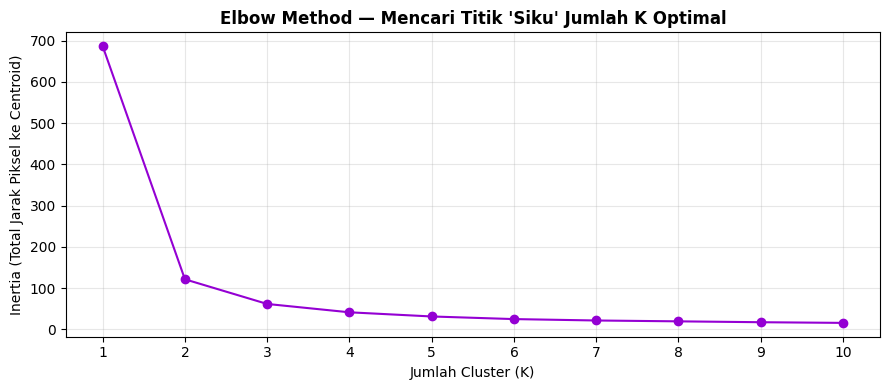

💡 Perhatikan grafiknya: penurunan inertia sangat tajam di awal, lalu melandai
   (membentuk pola seperti siku/elbow). Titik 'siku' tersebut adalah kandidat nilai K
   yang cukup baik -- penambahan K setelah titik itu tidak banyak membantu lagi.


In [14]:
# Ambil sampel piksel acak agar proses Elbow Method lebih cepat (sekadar demonstrasi visual)
np.random.seed(42)
data_piksel_full = china.reshape(-1, 3) / 255.0
sampel_piksel = data_piksel_full[np.random.choice(len(data_piksel_full), 2000, replace=False)]

daftar_k_elbow = range(1, 11)
daftar_inertia = []

print("⏳ Menghitung inertia untuk setiap nilai K (demonstrasi Elbow Method)...")
for k in daftar_k_elbow:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(sampel_piksel)
    daftar_inertia.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(list(daftar_k_elbow), daftar_inertia, marker="o", color="darkviolet")
plt.title("Elbow Method — Mencari Titik 'Siku' Jumlah K Optimal", fontsize=12, fontweight="bold")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia (Total Jarak Piksel ke Centroid)")
plt.xticks(list(daftar_k_elbow))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Perhatikan grafiknya: penurunan inertia sangat tajam di awal, lalu melandai")
print("   (membentuk pola seperti siku/elbow). Titik 'siku' tersebut adalah kandidat nilai K")
print("   yang cukup baik -- penambahan K setelah titik itu tidak banyak membantu lagi.")

## **💾 7. Membandingkan Ukuran File: Memahami Konsep Kompresi Gambar**

Selain efek visual, color quantization juga punya manfaat praktis di dunia nyata: **kompresi
gambar**. Dengan mengurangi jumlah warna unik, ukuran file gambar bisa berkurang signifikan
karena lebih sedikit variasi data yang perlu disimpan.

                 Versi  Ukuran (KB)
0  Asli (jutaan warna)        479.4
1        K-Means (K=2)         17.2
2        K-Means (K=4)         47.3
3       K-Means (K=10)        102.8


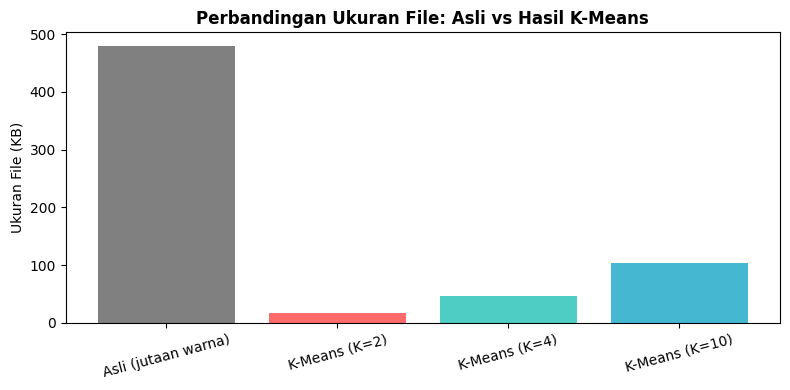


💡 Semakin sedikit warna unik dalam gambar (K kecil), umumnya semakin kecil pula
   ukuran file PNG-nya -- karena format PNG memanfaatkan pengulangan pola warna
   yang sama untuk kompresi. Inilah salah satu prinsip dasar di balik kompresi gambar
   di dunia nyata (misalnya format GIF yang dibatasi maksimal 256 warna).


In [15]:
from PIL import Image

os.makedirs("hasil_kmeans", exist_ok=True)

# Simpan gambar asli untuk pembanding ukuran file
Image.fromarray(china).save("hasil_kmeans/asli.png")
ukuran_asli_kb = os.path.getsize("hasil_kmeans/asli.png") / 1024

daftar_ukuran = [{"Versi": "Asli (jutaan warna)", "Ukuran (KB)": round(ukuran_asli_kb, 1)}]

for k in nilai_k_list:
    gambar_hasil, _ = hasil_kmeans[k]
    nama_file = f"hasil_kmeans/kmeans_k{k}.png"
    Image.fromarray(gambar_hasil).save(nama_file)
    ukuran_kb = os.path.getsize(nama_file) / 1024
    daftar_ukuran.append({"Versi": f"K-Means (K={k})", "Ukuran (KB)": round(ukuran_kb, 1)})

import pandas as pd
df_ukuran = pd.DataFrame(daftar_ukuran)
print(df_ukuran)

plt.figure(figsize=(8, 4))
plt.bar(df_ukuran["Versi"], df_ukuran["Ukuran (KB)"], color=["gray", "#FF6B6B", "#4ECDC4", "#45B7D1"])
plt.title("Perbandingan Ukuran File: Asli vs Hasil K-Means", fontsize=12, fontweight="bold")
plt.ylabel("Ukuran File (KB)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\n💡 Semakin sedikit warna unik dalam gambar (K kecil), umumnya semakin kecil pula")
print("   ukuran file PNG-nya -- karena format PNG memanfaatkan pengulangan pola warna")
print("   yang sama untuk kompresi. Inilah salah satu prinsip dasar di balik kompresi gambar")
print("   di dunia nyata (misalnya format GIF yang dibatasi maksimal 256 warna).")

## **🎯 8. Tugas Eksplorasi Mandiri**

Sekarang giliran Anda mencoba sendiri! Gunakan kode di bawah ini untuk:

1. Mengunggah foto wajah Anda sendiri atau foto pemandangan favorit
2. Mencoba berbagai nilai `jumlah_warna` (misalnya K=2, K=4, K=10, K=20)
3. Mengamati pada nilai K berapa hasilnya mulai terasa "natural" kembali

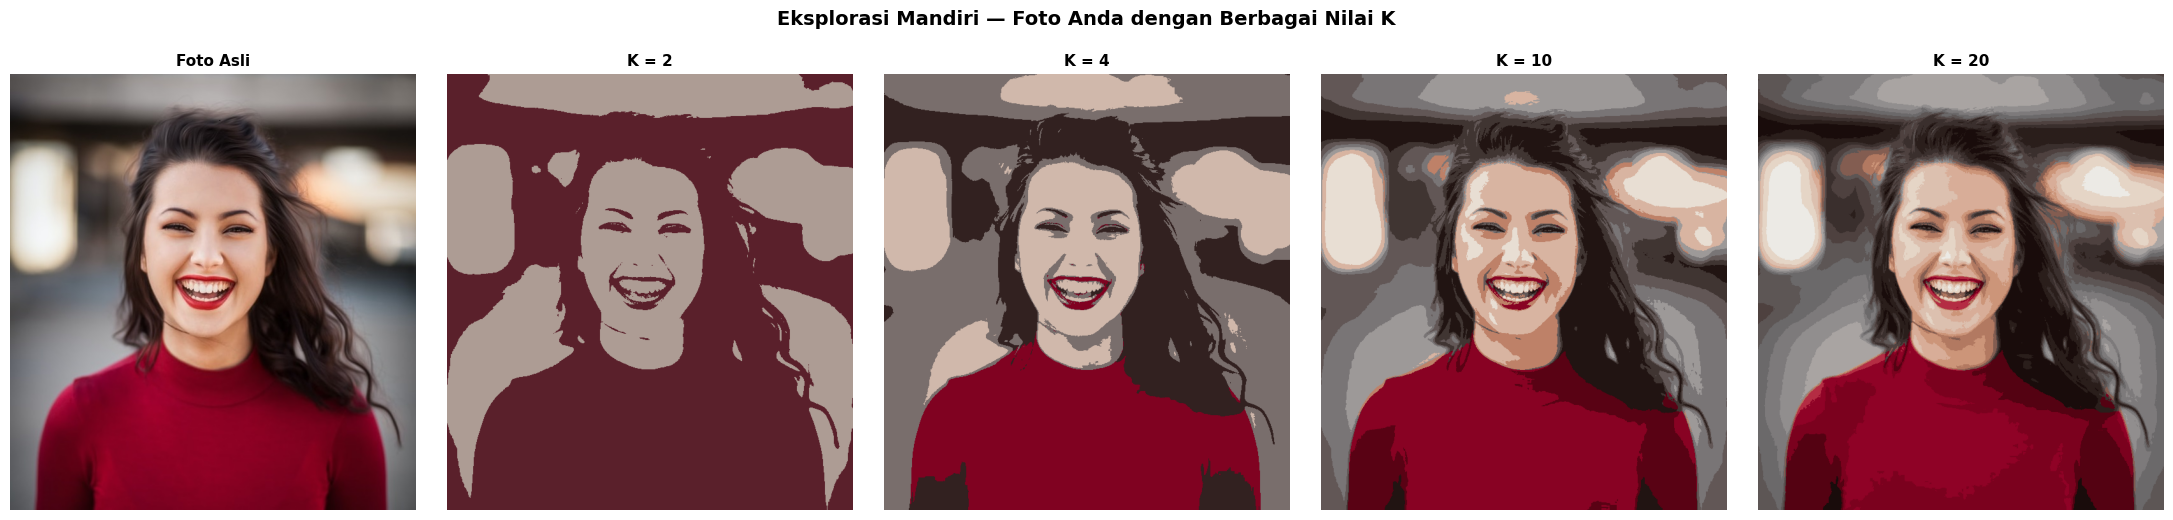

In [16]:
# ============================================================
# TUGAS EKSPLORASI MANDIRI
#
# Ganti path di bawah ini dengan foto Anda sendiri, lalu jalankan cell ini.
# Pastikan file foto berada di folder yang sama dengan notebook ini.
# ============================================================

PATH_FOTO_SENDIRI = "lady.jpg"  # <-- ganti dengan nama file foto Anda

if os.path.exists(PATH_FOTO_SENDIRI):
    foto_sendiri = np.array(Image.open(PATH_FOTO_SENDIRI).convert("RGB"))

    nilai_k_eksplorasi = [2, 4, 10, 20]
    fig, axes = plt.subplots(1, len(nilai_k_eksplorasi) + 1, figsize=(22, 5))

    axes[0].imshow(foto_sendiri)
    axes[0].set_title("Foto Asli", fontsize=11, fontweight="bold")
    axes[0].axis("off")

    for ax, k in zip(axes[1:], nilai_k_eksplorasi):
        hasil, _ = efek_kmeans(foto_sendiri, k)
        ax.imshow(hasil)
        ax.set_title(f"K = {k}", fontsize=11, fontweight="bold")
        ax.axis("off")

    plt.suptitle("Eksplorasi Mandiri — Foto Anda dengan Berbagai Nilai K",
                 fontsize=14, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️  File '{PATH_FOTO_SENDIRI}' tidak ditemukan.")
    print("   Letakkan foto Anda di folder yang sama dengan notebook ini,")
    print("   lalu ganti nilai PATH_FOTO_SENDIRI sesuai nama file foto Anda.")

## **🎓 Kesimpulan Sesi 4 & Penutup Modul**

Di sesi penutup ini, kita telah:

1. Memahami konsep **Unsupervised Learning** melalui **Color Quantization** menggunakan K-Means
2. Melihat bagaimana komputer menemukan warna dominan **tanpa diberi tahu** warna apa itu
   sebelumnya — inti dari pembelajaran tanpa kunci jawaban
3. Bereksperimen langsung mengubah parameter K dan mengamati efeknya secara visual
4. Mendapat wawasan tentang **Elbow Method** sebagai cara matematis menentukan K
5. Memahami kaitan praktis antara color quantization dan **kompresi gambar** di dunia nyata

---

### **🗺️ Rekap Perjalanan Modul 3 — AI & Machine Learning**

| Sesi | Fokus | Jenis Pembelajaran |
|---|---|---|
| Sesi 1 | Pipeline ML lengkap pada data Structured (ukuran baju) | Supervised Learning |
| Sesi 2 | EDA citra menyeluruh & Feature Extraction (daun) | Persiapan data Unstructured |
| Sesi 3 | Training & evaluasi model klasifikasi (KNN, SVM) | Supervised Learning |
| Sesi 4 | Color Quantization & eksplorasi visual (K-Means) | Unsupervised Learning |

Selamat! Anda telah menempuh perjalanan lengkap dari data Structured yang rapi, hingga
menjinakkan data Unstructured berupa gambar, melatih model klasifikasi, dan mengeksplorasi
sisi visual dari Unsupervised Learning. 🎉